In [1]:
import pandas as pd
import model as m
import matplotlib.pyplot as plt
import numpy as np

2024-03-04 21:00:24.185267: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-03-04 21:00:24.210888: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2024-03-04 21:00:24.331908: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-04 21:00:24.331967: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-04 21:00:24.350407: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to

In [2]:
dataset_path = 'Data/trainign_dataset_51270_microarray_adjusted.csv'
df_orignal = pd.read_csv(dataset_path)

/tmp/ipykernel_682306/29555212.py:2: DtypeWarning: Columns (51280) have mixed types. Specify dtype option on import or set low_memory=False.
  df_orignal = pd.read_csv(dataset_path)


In [3]:
df = df_orignal
#df["Experiment"]=df_orignal["Experiment"]
df['Age_group'] = pd.cut(df["Age"], bins=[-np.inf, 35, 65, np.inf], labels=[1, 2, 3], right=False)
def map_categorical_to_int(df):
    import pandas as pd

    # Get unique values from the 'Experiment' column
    unique_experiments = df['Experiment'].unique()

    # Create a mapping dictionary for the unique values to integers
    mapping = {experiment: i for i, experiment in enumerate(unique_experiments)}

    # Map the 'Experiment' column to integers using the mapping dictionary
    df['Experiment'] = df['Experiment'].map(mapping)

    return df
df = map_categorical_to_int(df)

In [6]:
X_train, X_test, y_train, y_test, z_train, z_test  = m.divide_test_train_dataset(df, test_size=0.01)

numeric_df = pd.concat([X_train, y_train], axis=1)
#all_df = pd.concat([X_train, y_train, z_train], axis=1)

In [ ]:
#all_df.columns

In [ ]:
#all_df
#z_lables = all_df[["Age","Experiment","Age_group","Age","Status","Sex","Sample"]]

In [4]:
import pandas as pd
import numpy as np

def augment_data(df, noise_level=0.1, z_label=None):
    # Assuming df is your original dataframe

    # Function to apply data augmentation
    def augment_data(row):
        # Example of a simple augmentation (adding random noise)
        augmented_row = row + np.random.normal(scale=noise_level)
        return augmented_row
    df_extended = pd.DataFrame()
    # Apply data augmentation to each row in the dataframe
    augmented_df = df.apply(augment_data, axis=1)
    if z_label is not None:
        df = pd.concat([df, z_label], axis=1, ignore_index=True)
        augmented_df = pd.concat([augmented_df, z_label], axis=1, ignore_index=True)

    # Concatenate the original dataframe and the augmented dataframe
    augmented_df = pd.concat([df, augmented_df], ignore_index=True)

    # Shuffle the rows of the augmented dataframe
    augmented_df = augmented_df.sample(frac=1).reset_index(drop=True)
    return augmented_df
# Now augmented_df contains your original dataframe with augmented data


In [7]:
numeric_df

,U48705,M87338,X51757,X69699,L36861,L13852,X55005,X79510,M21121,J02843,...,W22117,AI028241,AI571298,AA149545,C18318,AI219073,AI205180,AI363375,Experiment,Age
198,1457.487519,-521.644906,259.469501,-1272.887914,-18.886232,126.586529,-535.092183,297.625049,-55.849369,266.789553,...,-13.188643,170.253421,136.479193,1330.280159,1.147454,-35.351053,-45.779535,-121.734743,0,51.01
741,-993.511099,483.204923,272.873665,480.155807,-5.855893,444.079061,134.680962,1441.826356,1045.452946,148.565090,...,36.102902,-208.946495,464.422611,-1093.893834,64.355270,54.577918,188.400150,-60.438396,12,25.69
671,-721.897044,37.479215,-34.664835,582.164225,-25.418843,73.783018,-1011.566219,-259.345984,638.232633,584.043766,...,-10.601686,-3.725722,-181.629943,-103.213295,-37.362943,15.724816,20.507712,-86.317238,10,33.99
144,1074.121079,1032.920718,122.545177,6288.210400,-137.603421,-335.895743,4675.160634,3.934098,-90.669780,63.906220,...,-9.450038,-132.635124,471.589467,-1555.604425,120.582274,32.261894,274.349592,114.684048,0,52.52
553,-714.373190,-154.792999,284.595833,-121.730399,264.037473,-311.632829,519.129716,37.177943,-159.877982,163.875402,...,9.863083,319.982922,316.324253,136.090008,-18.574411,11.456187,234.425828,-94.021186,6,41.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612,-833.533385,-509.444047,94.391578,2582.177870,112.553404,23.776006,459.320506,437.088225,-17.792081,126.277513,...,44.455849,-195.462219,341.660803,-923.997887,-21.742278,23.559687,444.759337,213.402025,7,59.00
361,-650.983360,89.545003,96.154539,190.154212,44.029986,80.473023,97.712130,123.736137,15.200706,-542.311417,...,6.436906,84.075871,49.576474,428.331690,14.130715,11.175381,58.914494,57.519669,4,35.00
354,-372.142818,89.545003,96.154539,190.154212,44.029986,80.473023,97.712130,304.703686,15.200706,-136.711526,...,6.436906,84.075871,49.576474,428.331690,14.130715,11.175381,58.914494,57.519669,4,41.00
689,470.732027,139.515776,573.067011,-210.099941,33.502485,248.399575,459.824683,200.463074,-69.150688,-164.374215,...,29.793786,119.922894,-22.746076,419.834002,20.677395,65.272421,31.317618,-49.319936,10,37.84


In [8]:
a_df = augment_data(numeric_df, noise_level=0.1, z_label=None)


In [ ]:
a_df_nn = m.remove_non_numeric_columns(a_df)

In [10]:
a_df['Experiment'] = a_df['Experiment'].round()
a_df

,U48705,M87338,X51757,X69699,L36861,L13852,X55005,X79510,M21121,J02843,...,W22117,AI028241,AI571298,AA149545,C18318,AI219073,AI205180,AI363375,Experiment,Age
0,1745.657312,-497.796041,55.128001,-165.359193,-250.720976,395.790537,78.256148,-442.053498,78.696999,54.102219,...,-7.493028,341.016129,-14.119234,255.546499,41.576511,0.534309,7.357047,-63.785755,0.0,46.812934
1,552.780490,232.988736,-24.080415,-1269.754828,-20.591211,41.705525,-100.257727,77.647169,-311.134759,-597.847987,...,-12.714822,151.041445,316.527773,219.451547,29.499015,6.995746,-17.942696,195.765731,10.0,37.003124
2,603.136963,134.254548,249.910757,879.980649,175.224445,136.631176,104.246644,78.583611,31.382117,54.321135,...,6.380512,83.537825,49.219001,425.586327,14.025025,11.082983,58.462852,57.151181,1.0,21.000000
3,-608.478027,70.764445,-290.292106,-1776.732646,-272.382342,-430.517458,-73.886024,-433.187408,-102.540376,-112.144216,...,60.088025,106.205885,-29.922070,-286.293610,17.901146,-25.396925,-79.400038,217.382449,0.0,54.840000
4,561.454653,436.031434,157.286994,-252.072606,214.170604,258.674984,-313.140125,-497.687406,-163.116225,438.148823,...,24.143101,336.923903,-30.560671,1145.799098,54.283812,14.114375,-36.832611,-104.050738,5.0,48.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1533,-833.533385,-509.444047,94.391578,2582.177870,112.553404,23.776006,459.320506,437.088225,-17.792081,126.277513,...,44.455849,-195.462219,341.660803,-923.997887,-21.742278,23.559687,444.759337,213.402025,7.0,59.000000
1534,-5075.310330,-2030.184812,-862.132319,-4369.118839,-317.219999,-1224.200213,-2469.037057,211.146360,-144.203740,-1170.268638,...,95.330831,-504.797986,783.982988,-2885.273847,-90.997239,-80.679999,-562.443839,-421.957063,6.0,62.000000
1535,-1488.957251,-586.176092,-31.580805,35.994379,499.977686,1109.234831,-519.948121,-315.027996,-202.649064,-515.947474,...,-9.674353,199.211772,1.293327,-455.789644,79.561639,42.497744,-49.859692,97.260751,0.0,56.080000
1536,112.335496,-125.735995,87.454430,-1604.499632,-291.236953,170.102864,246.205281,-180.476068,169.296718,-506.784527,...,-15.730430,335.785941,-32.350821,1732.642545,15.397191,38.648028,27.255738,12.127773,0.0,49.630464


In [ ]:
numeric_df

In [ ]:

plt.hist(a_df["Age"], bins=20)

In [11]:
balanced_df, unselected_df = m.balance_classes(a_df)
balanced_df

,U48705,M87338,X51757,X69699,L36861,L13852,X55005,X79510,M21121,J02843,...,W22117,AI028241,AI571298,AA149545,C18318,AI219073,AI205180,AI363375,Experiment,Age
1460,-1269.303296,1523.470977,-4584.638014,-2150.792341,222.952544,-430.917566,815.858556,-1741.516168,374.057989,-1145.046971,...,6.321506,83.175495,48.922647,423.731677,13.932739,10.991873,58.055478,56.902496,9.0,21.000000
132,-475.535671,175.650308,131.087462,524.057080,-146.500002,-144.551327,155.048199,78.276642,-96.828297,96.500843,...,0.000198,37.577507,-66.642408,-271.855448,8.244504,-29.074415,115.094007,175.595005,2.0,34.000000
203,371.103075,-636.812875,56.524087,275.742648,225.469811,293.385005,-520.209111,385.849854,155.980360,-1.180025,...,19.781239,143.858849,189.406033,-667.776729,21.106720,-18.863484,-21.774073,181.251623,5.0,34.988309
1377,-1774.628140,-70.881895,-3447.720282,-2001.403074,-2006.265508,-254.651842,-2373.516828,-945.228269,-98.546023,-1501.102358,...,6.321506,83.175495,48.922647,423.731677,13.932739,10.991873,58.055478,56.902496,9.0,22.000000
429,-564.847445,558.767791,2.898176,370.791552,270.798724,220.638533,558.320721,42.344197,-64.505095,159.020194,...,6.367833,84.026391,49.513627,428.359106,14.063365,11.106583,58.848955,57.464158,11.0,30.711596
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1473,44.187484,222.396540,222.194115,75.417965,-96.805192,18.769031,-107.904721,120.136917,-150.338000,-181.808700,...,-17.748268,5.669581,68.789640,-1336.974463,121.434777,-36.884062,-210.453586,-197.508042,3.0,68.290000
1520,1118.849306,375.547442,-208.916398,-306.943215,-341.558749,-200.246209,108.134982,180.271662,164.720032,333.020247,...,15.301978,-109.110335,44.958379,1390.748358,-2.079191,29.471535,354.574397,-126.193259,5.0,66.143226
1525,-778.496640,466.582370,101.835137,215.676324,225.453984,-37.139439,-6.355164,1480.470603,732.378931,-77.062131,...,31.668374,-276.700935,346.664835,-1312.282652,60.198711,44.905575,19.793885,-9.936937,12.0,65.480000
1528,2704.266208,215.928580,9.422175,-1108.571216,-154.236394,616.165515,-459.871784,-41.031118,277.887998,3.642791,...,-24.797475,270.386896,-32.829617,694.742065,31.560660,-33.640810,80.930605,-89.626855,6.0,66.000000


In [12]:
balanced_df_experiments = balanced_df['Experiment']
balanced_df.drop('Experiment', axis=1, inplace=True)

(array([13., 51., 36., 28., 30., 14.,  6., 18., 17., 37., 48., 17.,  5.,
         7., 66., 36., 22., 25., 17.,  2.]),
 array([18.        , 21.27925565, 24.5585113 , 27.83776696, 31.11702261,
        34.39627826, 37.67553391, 40.95478957, 44.23404522, 47.51330087,
        50.79255652, 54.07181217, 57.35106783, 60.63032348, 63.90957913,
        67.18883478, 70.46809044, 73.74734609, 77.02660174, 80.30585739,
        83.58511304]),
 <BarContainer object of 20 artists>)

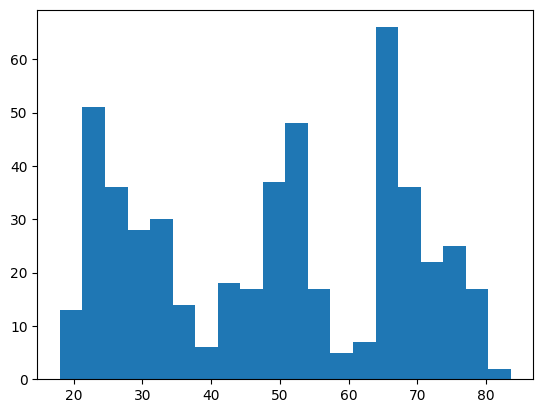

In [13]:
plt.hist(balanced_df["Age"], bins=20)

In [14]:
balanced_df["Age"].round().value_counts()

Age
66.0    28
68.0    22
26.0    22
34.0    21
50.0    21
        ..
18.0     1
57.0     1
60.0     1
39.0     1
36.0     1
Name: count, Length: 61, dtype: int64

In [ ]:
#balanced_df["Age_group"].value_counts()

In [15]:
training_data = balanced_df
my_model = m.Model(training_data)
normalized_X_train, normalized_X_test_fs = my_model.prepare_data(df=training_data, lasso_alpha=0.1, two_step=False)
my_model.train(normalize_X_train=normalized_X_train, 
                epochs=7500, optimizer='adam',
                loss='mse', metrics=['mae'])

/home/karen/Documents/GitHub/Identify_muscle_age_genes/deep_learning/.venv/lib/python3.10/site-packages/keras/src/layers/core/dense.py:85: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 836us/step


In [ ]:
m.plot_model(my_model.model, 'model.png', show_shapes=True)


In [16]:
results, error = my_model.test(normalized_X_test_fs, my_model.y_test)


MAE: 8.385
Loss: 128.404
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 752us/step


In [17]:
pd.DataFrame(my_model.y_test)

,Age
1116,51.350000
1379,80.000000
275,23.325057
577,74.000000
789,50.051324
...,...
1430,67.000000
181,51.149288
249,21.478837
704,50.608884


In [18]:
results

,Actual,Predicted
0,51.350000,51.498569
1,80.000000,70.130478
2,23.325057,59.420055
3,74.000000,66.930923
4,50.051324,48.185886
...,...,...
94,67.000000,62.906643
95,51.149288,63.692692
96,21.478837,32.999451
97,50.608884,62.712471


In [19]:
print(error)

[128.40428161621094, 8.384634017944336]


In [24]:
my_model.z_test

,Age
1116,51.350000
1379,80.000000
275,23.325057
577,74.000000
789,50.051324
...,...
1430,67.000000
181,51.149288
249,21.478837
704,50.608884


MAE: 4.910
Loss: 48.106
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 662us/step
        Actual  Predicted  Experiment
0    21.000000  30.271927         9.0
1    34.000000  32.835407         2.0
2    34.988309  48.804287         5.0
3    22.000000  30.271927         9.0
4    30.711596  30.260834        11.0
..         ...        ...         ...
490  68.290000  65.240768         3.0
491  66.143226  62.496632         5.0
492  65.480000  62.460075        12.0
493  66.000000  62.714069         6.0
494  77.070877  68.021935         1.0

[495 rows x 3 columns]


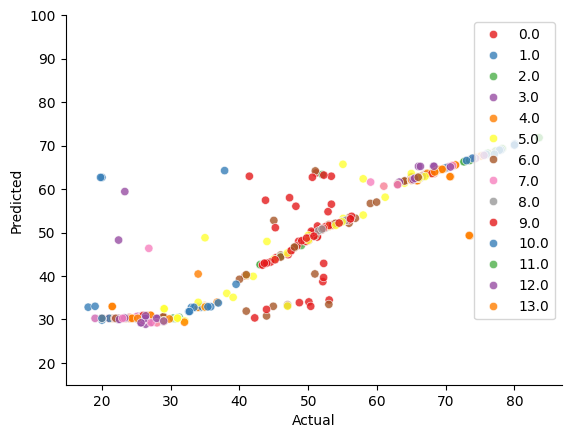

In [29]:
y = balanced_df['Age']
z = balanced_df_experiments
z = pd.DataFrame(z, columns=['Experiment'])
X = balanced_df.drop('Age', axis=1, inplace=False)
X = my_model.scaler.transform(X)
X = pd.DataFrame(X, columns=balanced_df.columns.drop('Age'))
X = X.loc[:, my_model.model_in_features]


results = m.evaluate_model(my_model.model, X, y )
m.plot_results(results, z)

In [28]:
z

1460     9.0
132      2.0
203      5.0
1377     9.0
429     11.0
        ... 
1473     3.0
1520     5.0
1525    12.0
1528     6.0
1530     1.0
Name: Experiment, Length: 495, dtype: float64

In [ ]:
X_train, X_test, y_train, y_test, z_train, z_test 


In [ ]:
X_test_2 = my_model.scaler.transform(X_test)
X_test_2 = pd.DataFrame(X_test_2)
X_test_2

In [ ]:
plt.hist(y_test, bins=20)

In [ ]:
len(my_model.model_in_features)

In [ ]:
X_test_2 = X_test_2.loc[:, my_model.model_in_features]
X_test_2

In [ ]:
m.evaluate_model(my_model.model, X_test_2, y_test)

In [20]:
results = m.evaluate_model(my_model.model, normalized_X_test_fs, my_model.y_test)

MAE: 8.385
Loss: 128.404
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 713us/step


In [ ]:
results = m.evaluate_model(my_model.model, X_test_2, y_test)

/tmp/ipykernel_682306/863757376.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(x='Actual', y='Predicted', data=results, palette='Set1', alpha=0.8, edgecolor='w')


<Axes: xlabel='Actual', ylabel='Predicted'>

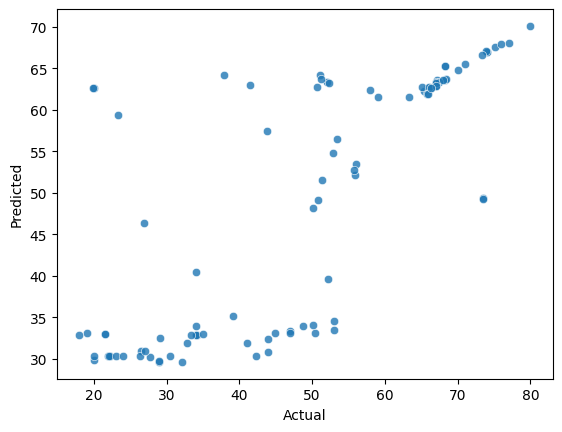

In [21]:
import seaborn as sns
sns.scatterplot(x='Actual', y='Predicted', data=results, palette='Set1', alpha=0.8, edgecolor='w')


In [ ]:
m.plot_results(results, z_test)

In [45]:

pd.DataFrame(X_train.drop('Experiment', axis=1, inplace=False).columns[my_model.model_in_features]).to_csv('Data/selected_features_287.csv', index=False)


In [38]:
X_train.columns

Index(['U48705', 'M87338', 'X51757', 'X69699', 'L36861', 'L13852', 'X55005',
       'X79510', 'M21121', 'J02843',
       ...
       'AI654857', 'W22117', 'AI028241', 'AI571298', 'AA149545', 'C18318',
       'AI219073', 'AI205180', 'AI363375', 'Experiment'],
      dtype='object', length=51277)